In [27]:
import json
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
dataset_dir = f'{parent_dir}/dataset'

with open(f'{dataset_dir}/mb_artists.json') as f:
    artists = json.load(f)
    
with open(f'{dataset_dir}/artists.json') as f:
    artists_og = json.load(f)

In [28]:
from integration import compute_match_scores

for (artist_og, artist_retrieved) in zip(artists_og, artists):
    compute_match_scores(artist_og, artist_retrieved)

In [29]:
scores_artists = []

for artist in artists:
    scores_artists.append(max([
        track_retrieved['matching-score']
        for track_retrieved in artist['artist-list']
    ]))

In [30]:
# top 5 lowest matching scores
sorted(scores_artists)[:10]

[0.4761613487745947,
 0.4912206628455922,
 0.534088136809941,
 0.576695400288663,
 0.6663986608270288,
 0.689548106877732,
 0.7071956670698132,
 0.7495145766807124,
 0.8134299018641463,
 0.8672933330307041]

In [31]:
len(scores_artists), len(artists)

(104, 104)

In [32]:
for low_score in sorted(scores_artists)[:10]:
    idx = scores_artists.index(low_score)
    best_artist = max(
        artists[idx]['artist-list'],
        key=lambda t: t['matching-score']
    )
    print(f"{artists_og[idx]['name']}: {best_artist['name']}, {best_artist['matching-score']}")

miss simpatia: Name, 0.4761613487745947
joey funboy: Name, 0.4912206628455922
eva rea: Name, 0.534088136809941
beba: Marina Barone, 0.576695400288663
hindaco: Name, 0.6663986608270288
mike24: Name, 0.689548106877732
guè pequeno: Guè, 0.7071956670698132
alfa: Alpha DJ, 0.7495145766807124
anna pepe: ANNA, 0.8134299018641463
lazza: Lazza, 0.8672933330307041


In [33]:
for low_score in sorted(scores_artists)[:6]:
    idx = scores_artists.index(low_score)
    best_artist = max(
        artists[idx]['artist-list'],
        key=lambda t: t['matching-score']
    )
    print(f"{artists_og[idx]['name']}, {best_artist}")

miss simpatia, {'id': 'a61fcba5-f0a8-4c81-a188-d70acedfd8c5', 'type': 'Person', 'ext:score': '96', 'name': 'Name', 'sort-name': 'Name', 'gender': 'female', 'disambiguation': 'Clara Moroni, Eurobeat', 'life-span': {'ended': 'false'}, 'matching-score': 0.4761613487745947}
joey funboy, {'id': 'a61fcba5-f0a8-4c81-a188-d70acedfd8c5', 'type': 'Person', 'ext:score': '96', 'name': 'Name', 'sort-name': 'Name', 'gender': 'female', 'disambiguation': 'Clara Moroni, Eurobeat', 'life-span': {'ended': 'false'}, 'matching-score': 0.4912206628455922}
eva rea, {'id': 'a61fcba5-f0a8-4c81-a188-d70acedfd8c5', 'type': 'Person', 'ext:score': '96', 'name': 'Name', 'sort-name': 'Name', 'gender': 'female', 'disambiguation': 'Clara Moroni, Eurobeat', 'life-span': {'ended': 'false'}, 'matching-score': 0.534088136809941}
beba, {'id': '0aa1fe1e-5e38-46e2-bb67-091507387e4c', 'type': 'Person', 'ext:score': '100', 'name': 'Marina Barone', 'sort-name': 'Barone, Marina', 'gender': 'female', 'country': 'IT', 'area': {'id

In [34]:
artists[0].keys()

dict_keys(['artist-list', 'artist-count', 'id_author'])

In [35]:
artists[50]['artist-list'][0].keys()

dict_keys(['id', 'type', 'ext:score', 'name', 'sort-name', 'country', 'area', 'isni-list', 'life-span', 'alias-list', 'tag-list', 'matching-score'])

In [36]:
artists[51]['artist-list'][0]['sort-name']

'Marsiglia, Johnny'

In [37]:
# Count artists with zero, one or more results
zero = []
one = []
more = []

for artist in artists:
    if artist['artist-count'] == 0:
        zero.append(artist)
    elif artist['artist-count'] == 1:
        one.append(artist)
    else:
        more.append(artist)

len(zero), len(one), len(more)

(0, 83, 21)

In [38]:
# open track dumps
with open(f'{dataset_dir}/mb_tracks_1.json') as f:
    tracks = json.load(f)
    
with open(f'{dataset_dir}/mb_tracks_2.json') as f:
    tracks.extend(json.load(f))
    
with open(f'{dataset_dir}/tracks.json') as f:
    tracks_og = json.load(f)

In [39]:
tracks_og[0]['title'], tracks[0]['recording-list'][0]['title']

('\u200bpolka 2 :-/', 'polka 2 :-/')

In [40]:
from integration import matching_score_track

matching_score_track(tracks_og[0], tracks[0]['recording-list'][0])

0.9918780848323527

In [41]:
from integration import compute_match_scores

for (track_og, track_retrieved) in zip(tracks_og, tracks):
    compute_match_scores(track_og, track_retrieved)

In [42]:
tracks[11000]['recording-list'][0]['matching-score']

0.8156894128987713

In [43]:
scores = []

for tracks_retrieved in tracks:
    scores.append(max([
        track_retrieved['matching-score']
        for track_retrieved in tracks_retrieved['recording-list']
    ]))

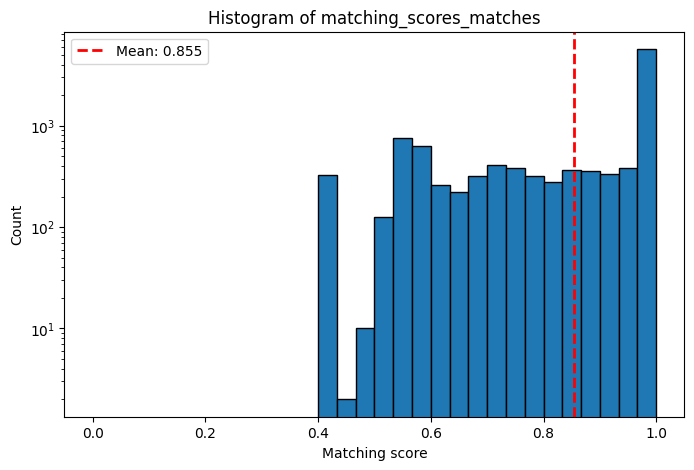

In [44]:
import matplotlib.pyplot as plt
from statistics import mean

plt.figure(figsize=(8,5))
m = mean(scores)
plt.hist(scores, bins=30, range=(0,1), edgecolor='black')
plt.xlabel('Matching score')
plt.ylabel('Count')
plt.title('Histogram of matching_scores_matches')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean: {m:.3f}")
plt.legend()
plt.yscale('log')
plt.show()

In [45]:
for low_score in sorted(scores)[:2500]:
    print(low_score)

0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416
0.42264973081037416


In [46]:
tracks[0]['recording-list'][0].keys()

dict_keys(['id', 'ext:score', 'title', 'length', 'artist-credit', 'release-list', 'isrc-list', 'artist-credit-phrase', 'matching-score'])

In [47]:
matching_title_artists = []

for track_og, track_retrieved in zip(tracks_og, tracks):

    best_track = max(
        track_retrieved['recording-list'],
        key=lambda t: t['matching-score']
    )

    # normalize titles
    title_match = best_track['title'].lower() == track_og['title'].lower()

    # extract artist names correctly
    retrieved_artists = [
        credit['artist']['name'].lower()
        for credit in best_track['artist-credit']
        if isinstance(credit, dict) and 'artist' in credit and 'name' in credit['artist']
    ]

    og_artist = track_og['primary_artist'].lower()
    artist_match = og_artist in retrieved_artists

    if title_match and artist_match:
        matching_title_artists.append((best_track, track_og))


In [48]:
len(matching_title_artists)

6849

In [49]:
from statistics import mean

matching_scores_matches = []

for match in matching_title_artists:
    matching_scores_matches.append(match[0]['matching-score'])

mean(matching_scores_matches)

0.9687348180890095

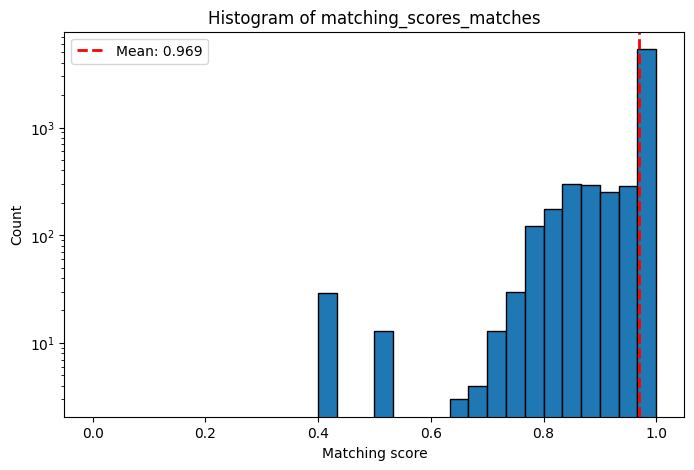

In [50]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
m = mean(matching_scores_matches)
plt.hist(matching_scores_matches, bins=30, range=(0,1), edgecolor='black')
plt.xlabel('Matching score')
plt.ylabel('Count')
plt.title('Histogram of matching_scores_matches')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean: {m:.3f}")
plt.legend()
plt.yscale('log')
plt.show()

In [51]:
not_matching = []


for track_og, track_retrieved in zip(tracks_og, tracks):

    best_track = max(
        track_retrieved['recording-list'],
        key=lambda t: t['matching-score']
    )

    # normalize titles
    title_match = best_track['title'].lower() == track_og['title'].lower()

    # extract artist names correctly
    retrieved_artists = [
        credit['artist']['name'].lower()
        for credit in best_track['artist-credit']
        if isinstance(credit, dict) and 'artist' in credit and 'name' in credit['artist']
    ]

    og_artist = track_og['primary_artist'].lower()
    artist_match = og_artist in retrieved_artists

    if not title_match and not artist_match:
        not_matching.append((best_track, track_og))

In [52]:
from statistics import mean

not_matching_scores = []

for not_match in not_matching:
    not_matching_scores.append(not_match[0]['matching-score'])

mean(not_matching_scores)

0.5780176811382993

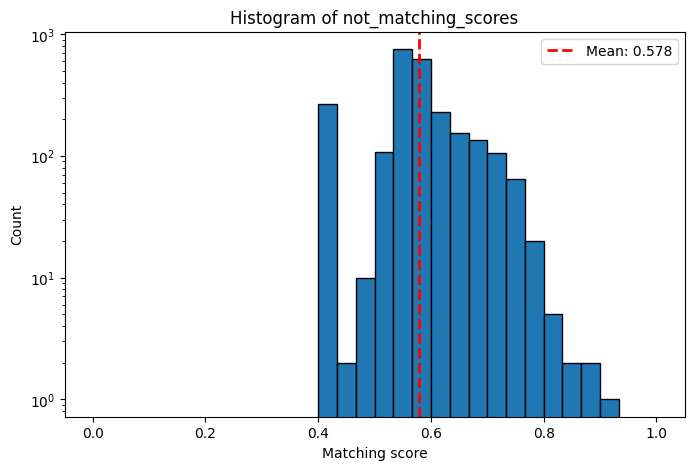

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
m = mean(not_matching_scores)
plt.hist(not_matching_scores, bins=30, range=(0,1), edgecolor='black')
plt.xlabel('Matching score')
plt.ylabel('Count')
plt.title('Histogram of not_matching_scores')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean: {m:.3f}")
plt.legend()
plt.yscale('log')
plt.show()

In [54]:
# Count artists with zero, one or more results
zero = []
one = []
more = []

for track in tracks:
    if track['recording-count'] == 0:
        zero.append(track)
    elif track['recording-count'] == 1:
        one.append(track)
    else:
        more.append(track)

len(zero), len(one), len(more)

(0, 6594, 4572)